In [1]:
import numpy as np
from scipy.sparse.linalg import eigsh

from tqdm import tqdm 

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize


import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from loaders import movielens

## Collaboration

In [2]:
def plot_relative_matrix(
    A,
    row_labels=None,
    col_labels=None,
    cmap_red='Reds',
    cmap_green='Greens',
    figsize=(8, 8)
):
    """
    Visualize a square matrix with off-diagonal coloring based on difference
    from diagonal elements of each row, and optional row/column labels.

    Parameters
    ----------
    A : np.ndarray
        Square matrix to visualize.
    row_labels : list[str] or list[int], optional
        Labels for rows. Defaults to range(n).
    col_labels : list[str] or list[int], optional
        Labels for columns. Defaults to range(n).
    """

    A = np.asarray(A)
    assert A.ndim == 2 and A.shape[0] == A.shape[1], "Matrix must be square"
    n = A.shape[0]

    # Default labels
    if row_labels is None:
        row_labels = list(range(n))
    if col_labels is None:
        col_labels = list(range(n))

    assert len(row_labels) == n and len(col_labels) == n, \
        "Row and column labels must have length equal to matrix dimension"

    # Differences relative to row diagonal
    row_diag = np.diag(A).reshape(-1, 1)
    diff = A - row_diag

    # Normalize by max absolute off-diagonal difference
    off_diag_mask = ~np.eye(n, dtype=bool)
    max_diff = np.max(np.abs(diff[off_diag_mask]))
    if max_diff == 0:
        max_diff = 1.0
    norm = Normalize(vmin=0, vmax=max_diff)

    fig, ax = plt.subplots(figsize=figsize)

    # Background
    ax.imshow(np.zeros_like(A), cmap='gray', vmin=0, vmax=1)

    # Fill each cell manually
    for i in range(n):
        for j in range(n):
            if i == j:
                color = "white"
            else:
                d = diff[i, j]
#                 intensity = norm(abs(d))
                intensity = abs(d)
    
                if d > 0:
                    color = plt.cm.get_cmap(cmap_red)(intensity)
                elif d < 0:
                    color = plt.cm.get_cmap(cmap_green)(intensity)
                else:
                    color = "white"

            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, facecolor=color))

            # Annotate numeric value
            ax.text(j, i, f"{A[i,j]:.2f}", ha="center", va="center", fontsize=10)

    # Tick settings
    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))
    ax.set_xticklabels(col_labels, rotation=45, ha='right')
    ax.set_yticklabels(row_labels)

    # Axes limits
    ax.set_xlim(-0.5, n - 0.5)
    ax.set_ylim(n - 0.5, -0.5)

    ax.set_aspect("equal")
    ax.set_title("Matrix Visualization (Relative to Diagonal)")
    plt.tight_layout()
    plt.show()


In [3]:
def get_proj_mtx(X, r):
    cov = X.T @ X
    w, v = eigsh(cov, k=r)
    return v @ v.T

def get_reconstruction_error(X, proj):
    X_approx = X @ proj
    return np.linalg.norm(X - X_approx) / np.linalg.norm(X)

In [29]:
movielens_obj = movielens.movielens(
    min_ratings = 1,
    min_users = 200,
    binary=True, 
    data_dir="../data/")
label_to_idxs = movielens_obj.get_user_labels("Age")
X = movielens_obj.get_X()
idx_to_metadata = movielens_obj.get_movie_metadata()
movie_title_to_idx = {
    metadata["title"]: idx 
    for idx, metadata in idx_to_metadata.items()
}

Shape before filtering:  (6040, 3706)
Shape after filtering:  (6040, 1426)


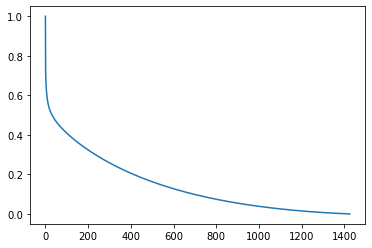

In [22]:
# Reconstruction error as a function of rank
d = X.shape[1]
w, v = eigsh(X.T @ X, k=d-1, which="LM")
w = np.flip(w)
norm = np.linalg.norm(X)**2
plt.plot([1 - (np.sum(w[:r]) / norm) for r in range(d)])

In [46]:
labels = [label for label in label_to_idxs]
g = len(labels)
r = 10
rng = np.random.default_rng(seed=0)

group_by_group_error = np.zeros((g, g))
for i, label_i in enumerate(labels):
    X_target = X[label_to_idxs[label_i]]
    
    for j, label_j in tqdm(enumerate(labels)):        
        train_row_idxs = label_to_idxs[label_i]
        if j != i:
            train_row_idxs = np.concatenate((
                label_to_idxs[label_i],
                rng.choice(
                    label_to_idxs[label_j], 
                    size = len(X_target),
                    replace = True)
            ))
            
        X_train = X[train_row_idxs]
        proj = get_proj_mtx(X_train, r)
        error = get_reconstruction_error(X_target, proj)
        
        group_by_group_error[i, j] = error
        

7it [00:00,  9.99it/s]
7it [00:01,  3.52it/s]
7it [00:03,  2.02it/s]
7it [00:02,  3.30it/s]
7it [00:01,  5.97it/s]
7it [00:01,  6.39it/s]
7it [00:00,  7.45it/s]


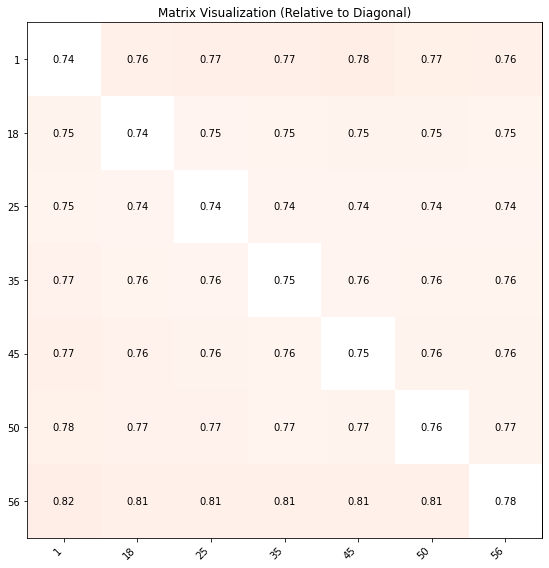

In [47]:
plot_relative_matrix(group_by_group_error, 
                    row_labels=labels,
                    col_labels=labels)

## Misrepresentation

In [32]:
proj_1 = get_proj_mtx(X[label_to_idxs["1"]], r=100)
proj_25 = get_proj_mtx(X[label_to_idxs["25"]], r=100)
proj_56 = get_proj_mtx(X[label_to_idxs["56"]], r=100)

In [33]:
def get_strongest_associations(proj, k=10):
    sorted_idxs_flat = np.argsort(proj, axis=None)

    # largest associations
    i_s, j_s = np.unravel_index(sorted_idxs_flat, proj.shape)
    num_printed = 0
    idx = 1
    print("Positive Associations")
    while num_printed < k:
        i = i_s[-idx]
        j = j_s[-idx]

        idx += 1

        if i == j:
            continue

        print(
            idx_to_metadata[j]['title'],
            "-->",
            idx_to_metadata[i]['title'],
            round(proj[i, j], 2))
        num_printed += 1

In [34]:
get_strongest_associations(proj_25)

Positive Associations
Godfather, The (1972) --> Godfather: Part II, The (1974) 0.29
Godfather: Part II, The (1974) --> Godfather, The (1972) 0.29
Close Shave, A (1995) --> Wrong Trousers, The (1993) 0.19
Wrong Trousers, The (1993) --> Close Shave, A (1995) 0.19
Being John Malkovich (1999) --> American Beauty (1999) 0.19
American Beauty (1999) --> Being John Malkovich (1999) 0.19
Star Wars: Episode VI - Return of the Jedi (1983) --> Star Wars: Episode V - The Empire Strikes Back (1980) 0.16
Star Wars: Episode V - The Empire Strikes Back (1980) --> Star Wars: Episode VI - Return of the Jedi (1983) 0.16
Wrong Trousers, The (1993) --> Grand Day Out, A (1992) 0.15
Grand Day Out, A (1992) --> Wrong Trousers, The (1993) 0.15


In [35]:
get_strongest_associations(proj_1 - proj_25)

Positive Associations
Saving Private Ryan (1998) --> X-Men (2000) 0.1
X-Men (2000) --> Saving Private Ryan (1998) 0.1
Bug's Life, A (1998) --> American Beauty (1999) 0.09
American Beauty (1999) --> Bug's Life, A (1998) 0.09
Schindler's List (1993) --> X-Men (2000) 0.09
X-Men (2000) --> Schindler's List (1993) 0.09
Shawshank Redemption, The (1994) --> L.A. Confidential (1997) 0.08
L.A. Confidential (1997) --> Shawshank Redemption, The (1994) 0.08
Shawshank Redemption, The (1994) --> Godfather, The (1972) 0.08
Godfather, The (1972) --> Shawshank Redemption, The (1994) 0.08


In [36]:
get_strongest_associations(proj_56 - proj_25)

Positive Associations
Star Wars: Episode IV - A New Hope (1977) --> Godfather: Part III, The (1990) 0.08
Godfather: Part III, The (1990) --> Star Wars: Episode IV - A New Hope (1977) 0.08
Star Wars: Episode I - The Phantom Menace (1999) --> Schindler's List (1993) 0.08
Schindler's List (1993) --> Star Wars: Episode I - The Phantom Menace (1999) 0.08
Boat, The (Das Boot) (1981) --> Shawshank Redemption, The (1994) 0.08
Shawshank Redemption, The (1994) --> Boat, The (Das Boot) (1981) 0.08
Shawshank Redemption, The (1994) --> Talented Mr. Ripley, The (1999) 0.07
Talented Mr. Ripley, The (1999) --> Shawshank Redemption, The (1994) 0.07
Total Recall (1990) --> Raiders of the Lost Ark (1981) 0.07
Raiders of the Lost Ark (1981) --> Total Recall (1990) 0.07


In [26]:
male_proj = get_proj_mtx(X[label_to_idxs["M"]], r=100)
female_proj = get_proj_mtx(X[label_to_idxs["F"]], r=100)

get_strongest_associations(female_proj - male_proj)

Positive Associations
Forrest Gump (1994) --> Jerry Maguire (1996) 0.09
Jerry Maguire (1996) --> Forrest Gump (1994) 0.09
Breakfast Club, The (1985) --> Raiders of the Lost Ark (1981) 0.08
Raiders of the Lost Ark (1981) --> Breakfast Club, The (1985) 0.08
Schindler's List (1993) --> Titanic (1997) 0.08
Titanic (1997) --> Schindler's List (1993) 0.08
Braveheart (1995) --> L.A. Confidential (1997) 0.08
L.A. Confidential (1997) --> Braveheart (1995) 0.08
Star Wars: Episode VI - Return of the Jedi (1983) --> Shakespeare in Love (1998) 0.08
Shakespeare in Love (1998) --> Star Wars: Episode VI - Return of the Jedi (1983) 0.08


In [44]:
def movie_overlap_by_group(X, 
                           label_to_idxs, 
                           movie_1_idx, 
                           movie_2_idx):
    for label, row_idxs in label_to_idxs.items():
        X_subset = X[row_idxs]
        
        movie_1_watchers = X_subset[:, movie_1_idx]
        movie_2_watchers = X_subset[:, movie_2_idx]
        
        overlap = [
            np.sum((movie_1_watchers > 0) & (movie_2_watchers == 0)),
            np.sum((movie_1_watchers > 0) & (movie_2_watchers > 0)),
            np.sum((movie_1_watchers == 0) & (movie_2_watchers > 0)),
        ]
        total = np.sum(overlap)
        print(f"{label}\n\
              1: {round(overlap[0]/total, 3)}\n\
              1&2: {round(overlap[1]/total, 3)}\n\
              2: {round(overlap[2]/total, 3)}\n\
              2|1: {round(overlap[1] / (overlap[0] + overlap[1]), 3)}\
              ")

In [45]:
movie_overlap_by_group(
    X,
    label_to_idxs,
    movie_title_to_idx["Star Wars: Episode IV - A New Hope (1977)"],
    movie_title_to_idx["Godfather: Part III, The (1990)"]
)

1
              1: 0.869
              1&2: 0.075
              2: 0.056
              2|1: 0.079              
18
              1: 0.825
              1&2: 0.121
              2: 0.054
              2|1: 0.128              
25
              1: 0.73
              1&2: 0.179
              2: 0.091
              2|1: 0.197              
35
              1: 0.794
              1&2: 0.135
              2: 0.071
              2|1: 0.145              
45
              1: 0.736
              1&2: 0.145
              2: 0.12
              2|1: 0.165              
50
              1: 0.725
              1&2: 0.171
              2: 0.104
              2|1: 0.191              
56
              1: 0.688
              1&2: 0.152
              2: 0.159
              2|1: 0.181              
